<div style="background-color: #121212; padding: 25px; border-radius: 12px; border-left: 6px solid #D4AF37; box-shadow: 0 4px 8px rgba(0,0,0,0.3);">
    <h1 style="color: #D4AF37; font-family: 'Cinzel', serif; margin-top: 0;">🏛️ Lumeria Analytics: Deep Learning for Sentiment Analysis</h1>
    <p style="color: #E0E0E0; font-size: 16px; line-height: 1.6;">
        Advanced Natural Language Processing pipeline evaluating <b>LSTM, GRU, and RNN</b> architectures. <br>
        This notebook covers robust text preprocessing, tokenization, and comparative accuracy metrics.
    </p>
</div>

In [1]:
# ==========================================
# 1. Environment Setup & Importing Libraries 
# ==========================================
import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, SimpleRNN, Dense, Dropout

2026-04-30 15:28:37.944444: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777562918.332557      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777562918.427870      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777562919.420747      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777562919.420820      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777562919.420825      23 computation_placer.cc:177] computation placer alr

<div style="background-color: #1A1A1A; padding: 15px; border-left: 4px solid #D4AF37;">
    <h3 style="color: #D4AF37;">1️⃣ Data Ingestion & Initial Cleaning</h3>
    <p style="color: #CCCCCC;">Loading the dataset, dropping missing values, and removing exact duplicates to ensure data integrity.</p>
</div>

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("📥 Loading Datasets...")


df1 = pd.read_excel('/kaggle/input/datasets/mernaabass/app-reviews/Dataset.xlsx')
df2 = pd.read_csv('/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/apps_reviews.csv')


df2 = df2[['review_text', 'review_score']].rename(columns={
    'review_text': 'content', 
    'review_score': 'score'
})

df1 = df1[['content', 'score']]


df1.dropna(subset=['content', 'score'], inplace=True)
df2.dropna(subset=['content', 'score'], inplace=True)

df_combined = pd.concat([df1, df2], ignore_index=True)

print(f"📊 Dataset 1 Shape: {df1.shape}")
print(f"📊 Dataset 2 Shape: {df2.shape}")
print(f"🚀 Combined Dataset Shape: {df_combined.shape}")


📥 Loading Datasets...
📊 Dataset 1 Shape: (199525, 2)
📊 Dataset 2 Shape: (466700, 2)
🚀 Combined Dataset Shape: (666225, 2)


<div style="background-color: #1A1A1A; padding: 15px; border-left: 4px solid #D4AF37;">
    <h3 style="color: #D4AF37;">2️⃣ Label Engineering</h3>
    <p style="color: #CCCCCC;">Removing neutral scores (3) and categorizing ratings into strictly Positive (1) and Negative (0) labels.</p>
</div>

In [3]:
df_combined = df_combined[df_combined['score'] != 3].copy()
df_combined['label'] = df_combined['score'].apply(lambda x: 1 if x > 3 else 0)

print(f"✅ Final Shape for Training: {df_combined.shape}")
print(df_combined['label'].value_counts())

✅ Final Shape for Training: (579071, 3)
label
1    331733
0    247338
Name: count, dtype: int64


<div style="background-color: #1A1A1A; padding: 15px; border-left: 4px solid #D4AF37;">
    <h3 style="color: #D4AF37;">3️⃣ Advanced Text Preprocessing</h3>
    <p style="color: #CCCCCC;">Applying Regex for cleaning, Stopwords removal, and Lemmatization to extract the root context.</p>
</div>

In [4]:
# ==========================================
# 🧹 Smart Text Cleaning 
# ==========================================

import re
import emoji

def smart_cleaner(text):
    if not isinstance(text, str):
        return str(text)
    
    # 1. تحويل الإيموجي لكلمات
    text = emoji.demojize(text)
    
    # 2. تنظيف الرموز وتوحيد المسافات (مع الاحتفاظ بالأرقام والحروف الإنجليزية)
    text = re.sub(r'[^a-zA-Z0-9\s:_-]', '', text)
    
    # 3. توحيد حالة الأحرف
    text = re.sub(r'\s+', ' ', text).strip().lower()
    
    # 4. إزالة الحروف المتكررة المبالغ فيها 
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    
    
    return text


df_combined['clean_content'] = df_combined['content'].apply(smart_cleaner)
df_combined = df_combined[df_combined['clean_content'].str.strip() != '']

print(f"Data ready! Total rows: {df_combined.shape[0]} 🚀")

Data ready! Total rows: 578516 🚀


<div style="background-color: #1A1A1A; padding: 15px; border-left: 4px solid #D4AF37;">
    <h3 style="color: #D4AF37;">4️⃣ Tokenization & Sequence Padding</h3>
    <p style="color: #CCCCCC;">Vectorizing the text space for neural network ingestion.</p>
</div>

In [5]:
# ==========================================
# 🧠 Step 4: NLP Tokenization (Full Data Setup)
# ==========================================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

vocab_size = 30000
max_length = 60   

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

tokenizer.fit_on_texts(df_combined['clean_content'].astype(str))

all_sequences = tokenizer.texts_to_sequences(df_combined['clean_content'].astype(str))

X_all_padded = pad_sequences(all_sequences, maxlen=max_length, padding='pre', truncating='post')

y_all = df_combined['label'].values

X_train_padded, X_test_padded, y_train, y_test = train_test_split(
    X_all_padded, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print("Text vectorized on FULL DATA successfully! 🎯")

Text vectorized on FULL DATA successfully! 🎯


<div style="background-color: #121212; padding: 20px; border-radius: 12px; border-left: 6px solid #D4AF37; margin-top: 20px;">
    <h2 style="color: #D4AF37; font-family: 'Cinzel', serif;">⚙️ Neural Network Architectures</h2>
    <p style="color: #E0E0E0;">Building RNN, GRU, and LSTM models to compare performance and accuracy metrics.</p>
</div>

In [6]:
# ==========================================
# 🚀 Step 5: Standard RNN, GRU & LSTM Models 
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, SimpleRNN, Dense, Dropout

embedding_dim = 64

# --- 1. Standard RNN Model ---
def build_rnn():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
        SimpleRNN(64, return_sequences=False), 
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# --- 2. Standard GRU Model ---
def build_gru():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
        GRU(64, return_sequences=False), 
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# --- 3. Standard LSTM Model ---
def build_lstm():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
        LSTM(64, return_sequences=False), 
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

rnn_model = build_rnn()
gru_model = build_gru()
lstm_model = build_lstm()

print("All 3 Standard Models built successfully! 🛠️🚀")

All 3 Standard Models built successfully! 🛠️🚀


I0000 00:00:1777563049.721820      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


<div style="background-color: #1A1A1A; padding: 15px; border-left: 4px solid #D4AF37;">
    <h3 style="color: #D4AF37;">5️⃣ Training & Evaluation Phase</h3>
    <p style="color: #CCCCCC;">Executing the models and comparing their validation accuracy.</p>
</div>

In [7]:
# ==========================================
# ⚙️ Step 6: Training with Early Stopping
# ==========================================
from tensorflow.keras.callbacks import EarlyStopping

epochs = 10 
batch_size = 256


early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("✨ Training Standard RNN...")
history_rnn = rnn_model.fit(X_train_padded, y_train, epochs=epochs, batch_size=batch_size, 
                            validation_split=0.1, callbacks=[early_stop], verbose=1)

print("\n✨ Training Standard GRU...")
history_gru = gru_model.fit(X_train_padded, y_train, epochs=epochs, batch_size=batch_size, 
                            validation_split=0.1, callbacks=[early_stop], verbose=1)

print("\n✨ Training Standard LSTM...")
history_lstm = lstm_model.fit(X_train_padded, y_train, epochs=epochs, batch_size=batch_size, 
                              validation_split=0.1, callbacks=[early_stop], verbose=1)

✨ Training Standard RNN...
Epoch 1/10


I0000 00:00:1777563052.045178      67 service.cc:152] XLA service 0x7cfe4400b460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777563052.045246      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777563052.724287      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


  22/1628 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5688 - loss: 0.6729

I0000 00:00:1777563054.827876      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1628/1628 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8217 - loss: 0.3991 - val_accuracy: 0.8861 - val_loss: 0.2952
Epoch 2/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8943 - loss: 0.2781 - val_accuracy: 0.8846 - val_loss: 0.3156
Epoch 3/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9021 - loss: 0.2601 - val_accuracy: 0.8843 - val_loss: 0.2938
Epoch 4/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9081 - loss: 0.2497 - val_accuracy: 0.8865 - val_loss: 0.2991
Epoch 5/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9163 - loss: 0.2292 - val_accuracy: 0.8853 - val_loss: 0.2971
Epoch 6/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9240 - loss: 0.2122 - val_accuracy: 0.8825 - val_loss: 0.3091
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

✨ Training Standard GRU...
Epoch 1/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8316 - loss: 0.3742 - val_accuracy: 0.8927 -

<div style="background-color: #1A1A1A; padding: 15px; border-left: 4px solid #D4AF37;">
    <h2 style="color: #D4AF37; font-family: 'Cinzel', serif;">📊 Step 6: Model Evaluation & Comprehensive Comparison ⚖️</h2>
    <p style="color: #CCCCCC;">
        In this phase, we will evaluate the models on two fronts: <br>
        1. <b>Learning Stability:</b> Visualizing Validation Accuracy & Loss over epochs. <br>
        2. <b>Final Performance:</b> Calculating final accuracy on unseen Test Data.
    </p>
</div>

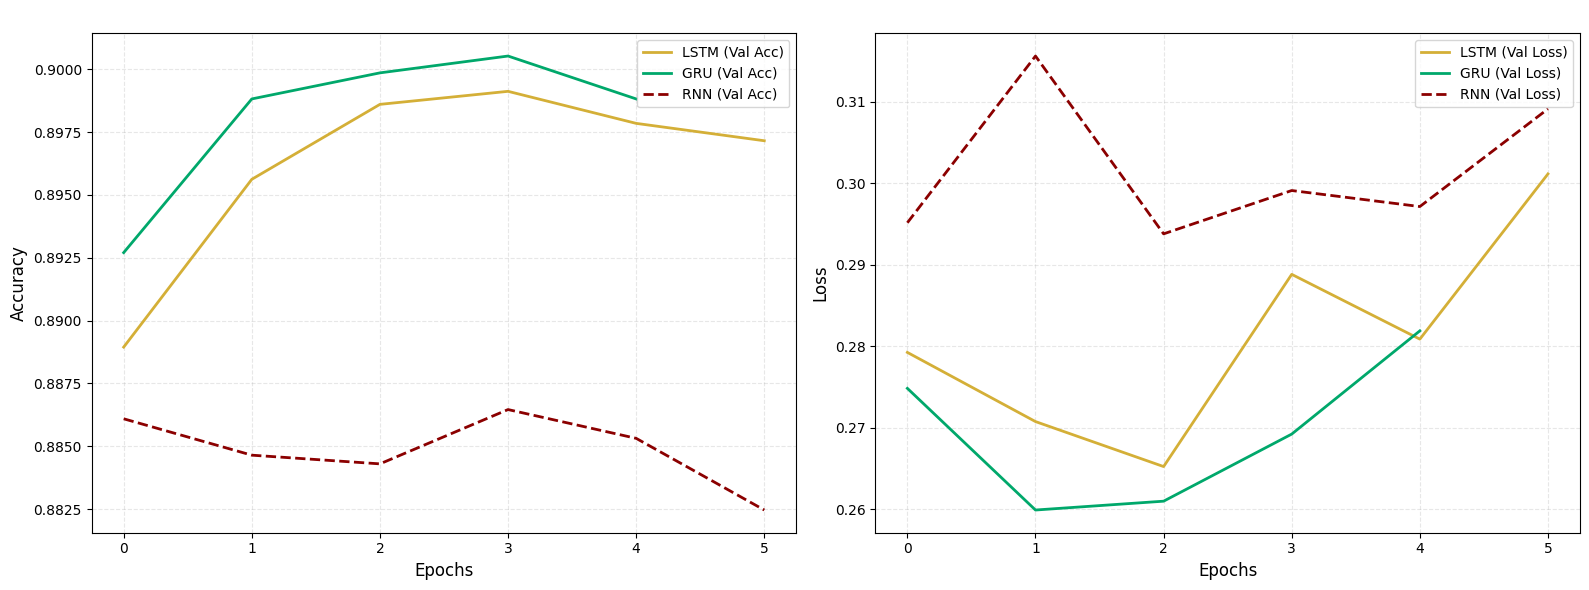

In [8]:
# ==========================================
# 1. Visualizing Training/Validation History
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

# Accuracy 
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['val_accuracy'], label='LSTM (Val Acc)', color='#D4AF37', linewidth=2) 
plt.plot(history_gru.history['val_accuracy'], label='GRU (Val Acc)', color='#00A86B', linewidth=2) 
plt.plot(history_rnn.history['val_accuracy'], label='RNN (Val Acc)', color='#8B0000', linestyle='dashed', linewidth=2) 
plt.title('Validation Accuracy Progression 📈', fontsize=14, color='white')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

# Loss 
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['val_loss'], label='LSTM (Val Loss)', color='#D4AF37', linewidth=2)
plt.plot(history_gru.history['val_loss'], label='GRU (Val Loss)', color='#00A86B', linewidth=2)
plt.plot(history_rnn.history['val_loss'], label='RNN (Val Loss)', color='#8B0000', linestyle='dashed', linewidth=2)
plt.title('Validation Loss Progression 📉', fontsize=14, color='white')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.style.use('dark_background') 
plt.tight_layout()
plt.show()


🏆 Final Test Accuracy Results:


,Model,Test Accuracy
0,Simple RNN,88.64%
1,GRU,90.15%
2,LSTM,90.18%


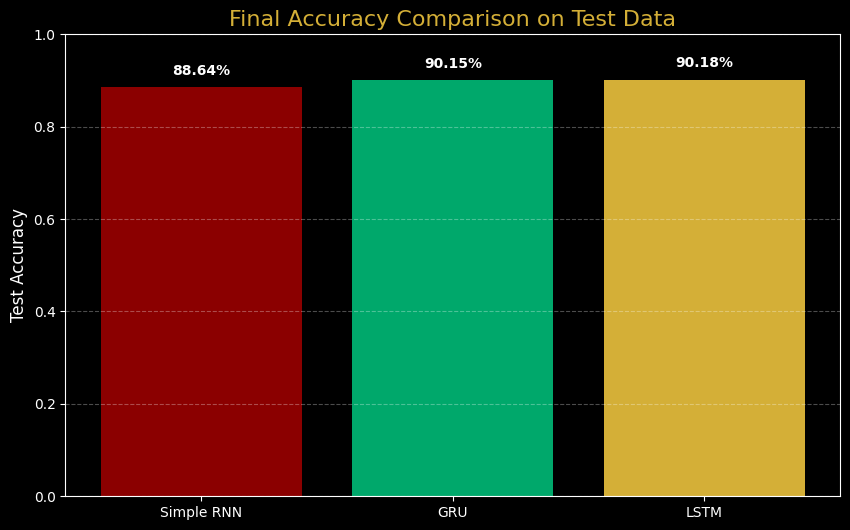

In [9]:
# ==========================================
# 2. Final Evaluation on Unseen Test Data
# ==========================================

# Evaluate on Test Data
loss_rnn, acc_rnn = rnn_model.evaluate(X_test_padded, y_test, verbose=0)
loss_gru, acc_gru = gru_model.evaluate(X_test_padded, y_test, verbose=0)
loss_lstm, acc_lstm = lstm_model.evaluate(X_test_padded, y_test, verbose=0)

results = pd.DataFrame({
    'Model': ['Simple RNN', 'GRU', 'LSTM'],
    'Test Accuracy': [acc_rnn, acc_gru, acc_lstm]
})

# Styling the results output (Table)
print("\n🏆 Final Test Accuracy Results:")
results_styled = results.style.background_gradient(cmap='YlOrBr').format({'Test Accuracy': '{:.2%}'})
display(results_styled)

# Plotting Final Comparison (Bar Chart)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(results['Model'], results['Test Accuracy'], color=['#8B0000', '#00A86B', '#D4AF37'])

plt.title('Final Accuracy Comparison on Test Data', color='#D4AF37', fontsize=16)
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim(0, 1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center', va='bottom', color='white', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

<div style="background-color: #121212; padding: 25px; border-radius: 12px; border-top: 4px solid #D4AF37; text-align: center; margin-top: 30px;">
    <h2 style="color: #D4AF37; font-family: 'Cinzel', serif;">🏺 Live Inference Test (GRU Engine) 🏺</h2>
    <p style="color: #E0E0E0;">
        Testing the chosen model on unseen, real-world application reviews. 
        <br><span style="font-size: 12px; color: #888;">(Non-English texts are assumed to be translated prior to this step via external API).</span>
    </p>
</div>

In [10]:
# ==========================================
# 🏺 Live Inference Test (GRU Engine) 🏺
# ==========================================

def test_review(review_text, model=gru_model):
    print(f"📝 Original Input: {review_text}")
    
  
    cleaned_text = smart_cleaner(review_text) 
    print(f"🧹 Cleaned Input: {cleaned_text}")
    
    # 2. (Tokenization & Pre-Padding)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='pre', truncating='post')
    
    # 3. 
    prediction = model.predict(padded_sequence, verbose=0)[0][0]
    
    # 4. 
    if prediction >= 0.5:
        sentiment = "Positive 🌟"
        color = "\033[92m" # Green
    else:
        sentiment = "Negative 🛑"
        color = "\033[91m" # Red
        
    print(f"{color}🤖 Model Verdict: {sentiment} (Confidence: {prediction:.2%})\033[0m")
    print("-" * 50)

# ==========================================
# 🚀 TEST
# ==========================================

test_review("This app is a masterpiece! totally love it 😍🔥")

test_review("Way too many ads interrupting my screen, worst experience 😡👎")

test_review("The application is very slow and lagging")

📝 Original Input: This app is a masterpiece! totally love it 😍🔥
🧹 Cleaned Input: this app is a masterpiece totally love it :smiling_face_with_heart-eyes::fire:
🤖 Model Verdict: Positive 🌟 (Confidence: 98.75%)
--------------------------------------------------
📝 Original Input: Way too many ads interrupting my screen, worst experience 😡👎
🧹 Cleaned Input: way too many ads interrupting my screen worst experience :enraged_face::thumbs_down:
🤖 Model Verdict: Negative 🛑 (Confidence: 1.09%)
--------------------------------------------------
📝 Original Input: The application is very slow and lagging
🧹 Cleaned Input: the application is very slow and lagging
🤖 Model Verdict: Negative 🛑 (Confidence: 10.12%)
--------------------------------------------------
